# ENPM673 Project 2 - Lane Detection Pipeline

Final video link (YouTube/Drive): `<PASTE HERE>`

## Pipeline Overview

This notebook implements a **frame-independent** classical CV lane detection pipeline.
Each frame is processed independently (no temporal tracking state is used).
A manually selected 4-point correspondence is used to compute homography and warp to bird's-eye view.
Preprocessing includes ROI cropping (**full width + bottom 400 px**), denoising, and edge detection.
Hough transform is used to detect lane candidate segments, then segments are split into left/right groups.
Candidate lines are extrapolated to form stable lane boundaries in ROI.
Polynomial fitting (`x=f(y)`, degree 2 by default) refines curved lanes in bird view.
Lane mesh/fill is created between left and right fitted boundaries and back-projected to original frame.
Optional curvature and turn-direction estimation are overlaid as text on the output frame.

In [94]:
import os
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


In [136]:
# Central configuration dictionary for the entire lane detection pipeline.
# Putting all tunable parameters here makes the notebook easier to debug,
# reproduce, and grade, because we do not need to search through many cells
# to change thresholds or file paths.

CONFIG = {
    # -----------------------------
    # Input / Output settings
    # -----------------------------
    "input_video": "import_video.mp4",   # input video file name or path
    "output_dir": "outputs",             # folder where processed results will be saved
    "output_suffix": "_lane.mp4",        # suffix appended to the output video file name

    # -----------------------------
    # ROI (Region of Interest)
    # -----------------------------
    "roi_height": 400,  # required by project spec: use full width + bottom 400 pixels only

    # -----------------------------
    # Edge detection settings
    # -----------------------------
    "edge_method": "canny",  # choose edge detector: "canny" or "sobel"

    # -----------------------------
    # Denoising settings
    # -----------------------------
    "denoise_kernel": 5,  # Gaussian blur kernel size used to reduce noise before edge detection

    # -----------------------------
    # Canny edge detector parameters
    # -----------------------------
    "canny_low": 60,      # lower threshold for Canny hysteresis
    "canny_high": 180,    # upper threshold for Canny hysteresis

    # -----------------------------
    # Sobel edge detector parameters
    # -----------------------------
    "sobel_ksize": 3,     # Sobel kernel size for gradient computation
    "sobel_thresh": 80,   # threshold applied to Sobel magnitude image

    # -----------------------------
    # Hough transform parameters
    # -----------------------------
    "hough_rho": 1,                    # distance resolution in pixels for Hough transform
    "hough_theta": np.pi / 180,        # angle resolution in radians (1 degree)
    "hough_threshold": 40,             # minimum votes needed for a line to be detected
    "hough_min_line_length": 30,       # shortest line segment allowed
    "hough_max_line_gap": 80,          # maximum allowed gap between segments to link them

    # -----------------------------
    # Lane candidate filtering
    # -----------------------------
    "min_abs_slope": 0.35,  # reject nearly horizontal lines; keep only lines steep enough to be lane candidates

    # -----------------------------
    # Polynomial fitting
    # -----------------------------
    "poly_degree": 2,  # degree of polynomial for fitting lane curves in bird's-eye view: x = f(y)

    # -----------------------------
    # Visualization / overlay settings
    # -----------------------------
    "overlay_alpha": 0.35,         # transparency of the filled lane region when blended onto original frame
    "lane_fill_color": (0, 200, 0),# BGR color for lane area fill
    "lane_line_color": (255, 80, 80),  # BGR color for fitted lane boundaries
    "line_thickness": 4,           # thickness used when drawing lane boundary lines

    # -----------------------------
    # Debug / sample visualization
    # -----------------------------
    "sample_frame_idx": 600,  # frame index used for demonstrating intermediate results in the notebook
}

# Create the output directory if it does not already exist.
# exist_ok=True prevents an error if the folder is already there.
os.makedirs(CONFIG["output_dir"], exist_ok=True)

# Print a quick confirmation so we know the config loaded correctly.
print("Config ready. Output dir:", CONFIG["output_dir"])

Config ready. Output dir: outputs


## Data Input

- Put the input video in the notebook working directory (or provide absolute path).
- This notebook defaults to `import_video.mp4`.
- In Colab, you can either upload directly or mount Google Drive and point `CONFIG["input_video"]` to that path.
- Processed outputs are saved under `outputs/`.

Video: import_video.mp4
FPS=30.00, Size=(1920, 1080), Frames=839


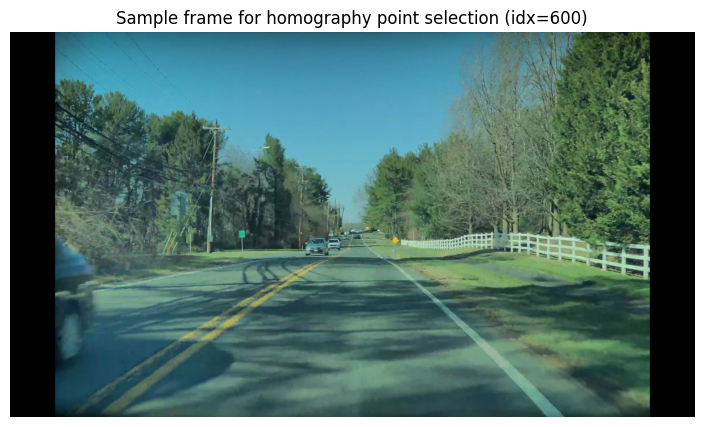

In [137]:
def load_video_info(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return fps, (width, height), frame_count


def get_frame_at(video_path, frame_idx):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise ValueError(f"Unable to read frame {frame_idx} from {video_path}")
    return frame


video_path = CONFIG["input_video"]
fps, (W, H), n_frames = load_video_info(video_path)
print(f"Video: {video_path}")
print(f"FPS={fps:.2f}, Size=({W}, {H}), Frames={n_frames}")

sample_idx = min(CONFIG["sample_frame_idx"], max(0, n_frames - 1))
sample_frame = get_frame_at(video_path, sample_idx)
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))
plt.title(f"Sample frame for homography point selection (idx={sample_idx})")
plt.axis("off")
plt.show()

## 4-Point Homography Setup

A fixed set of four source points is defined on a straight-road frame to cover the current lane region.  
These points are ordered as:

[left-top, right-top, right-bottom, left-bottom]

Using these source points, a corresponding rectangular set of destination points is created in the bird-view plane.  
The homography matrix is then computed and applied to warp the original frame into a bird’s-eye view.

This step makes the lane boundaries appear more vertical and parallel, which simplifies the later steps of edge detection, Hough line detection, and polynomial fitting.

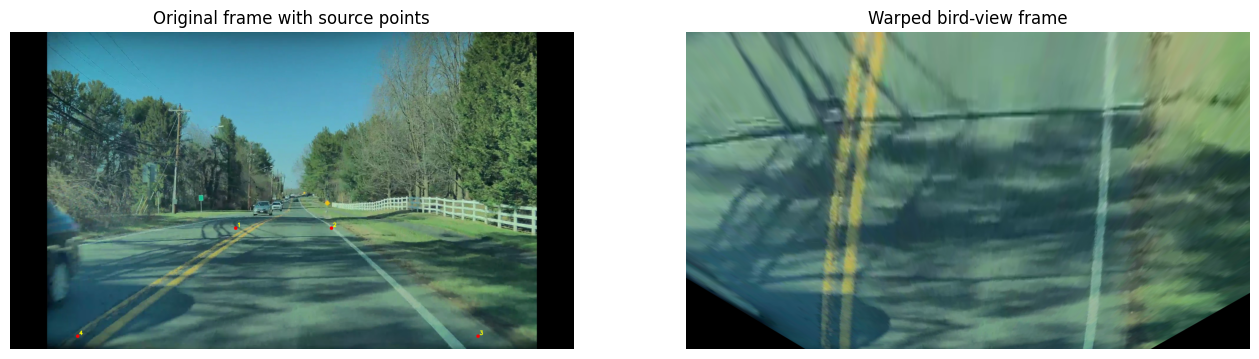

In [138]:
# Fixed 4 source points on a straight-road frame.
# Order: [left-top, right-top, right-bottom, left-bottom]
src_pts = np.float32([
    [W * 0.40, H * 0.62],  # left-top
    [W * 0.57, H * 0.62],  # right-top
    [W * 0.83, H * 0.96],  # right-bottom
    [W * 0.12, H * 0.96],  # left-bottom
])

# Destination points in bird-view plane.
# These form a rectangle so that the lane region is warped into a top-down view.
bird_margin_x = int(0.25 * W)
dst_pts = np.float32([
    [bird_margin_x, 0],              # left-top
    [W - bird_margin_x, 0],          # right-top
    [W - bird_margin_x, H],          # right-bottom
    [bird_margin_x, H],              # left-bottom
])

# Compute homography and its inverse
H_mat = cv2.getPerspectiveTransform(src_pts, dst_pts)
H_inv = np.linalg.inv(H_mat)

# Warp the sample frame into bird's-eye view
warped_sample = cv2.warpPerspective(sample_frame, H_mat, (W, H))

# Visualize selected source points on the original frame
viz = sample_frame.copy()
for i, (x, y) in enumerate(src_pts.astype(int), start=1):
    cv2.circle(viz, (x, y), 6, (0, 0, 255), -1)
    cv2.putText(
        viz, str(i), (x + 5, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2
    )

# Show original frame and warped bird-view frame
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original frame with source points")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(warped_sample, cv2.COLOR_BGR2RGB))
axes[1].set_title("Warped bird-view frame")
axes[1].axis("off")

plt.show()

## Step 1: Preprocessing

Preprocessing follows assignment requirements:

- **Denoising:** Gaussian blur is used to suppress high-frequency noise while keeping edge structures reasonably stable.
- **Edge detection:** Canny (default) is used for robust binary edge extraction; Sobel is also provided as an alternative.
- **ROI:** full-width bottom **400 px** are cropped to satisfy the project ROI rule and reduce computation.

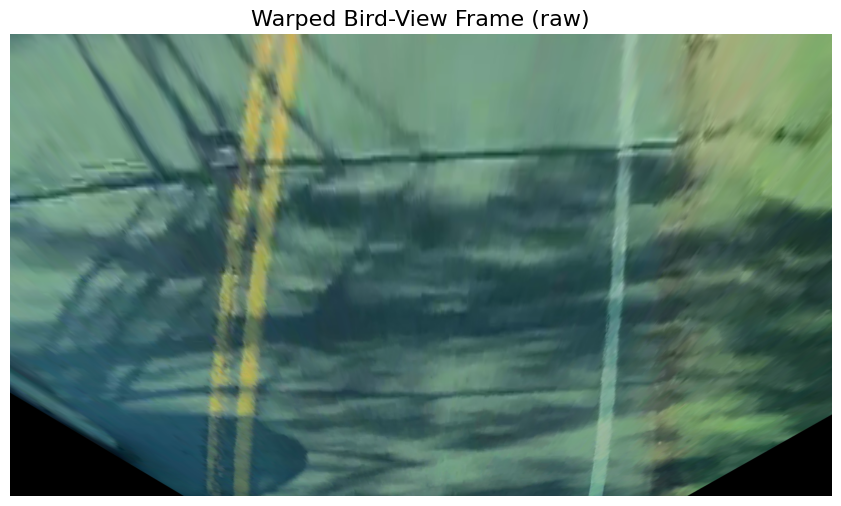

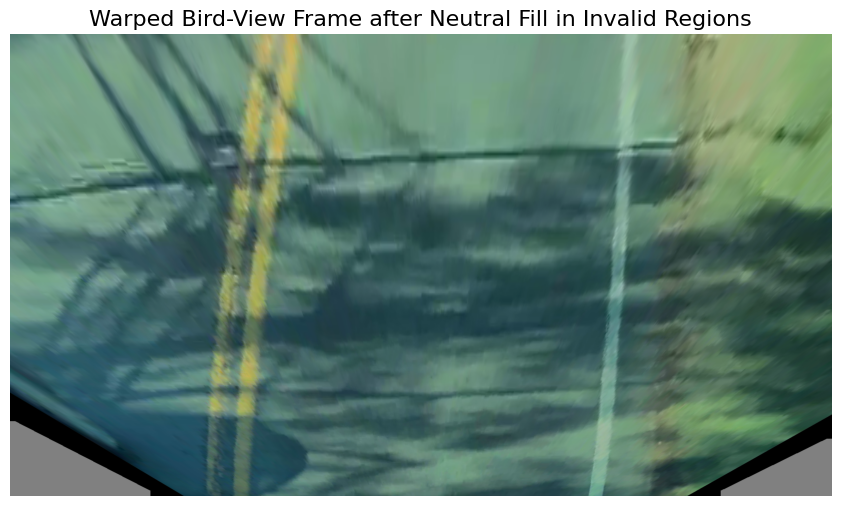

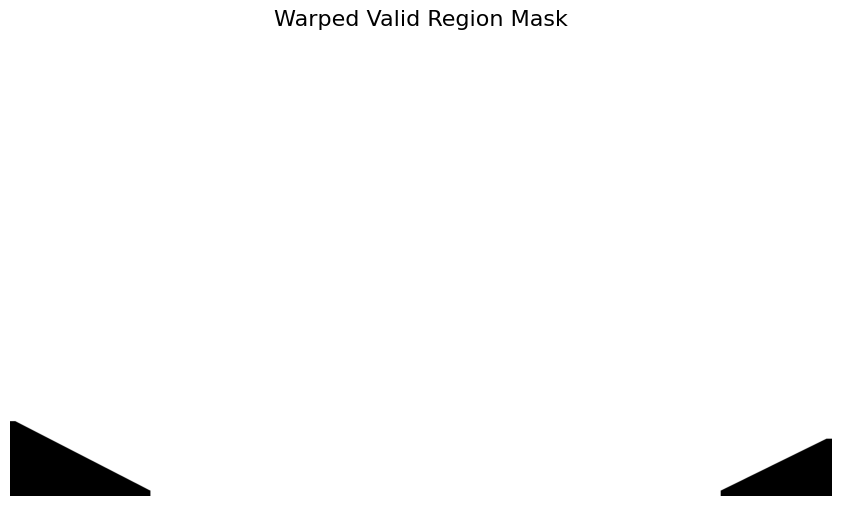

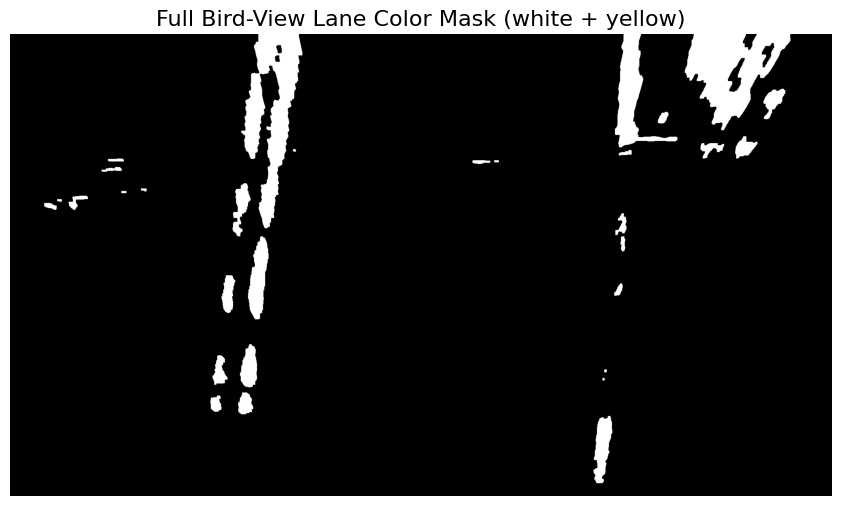

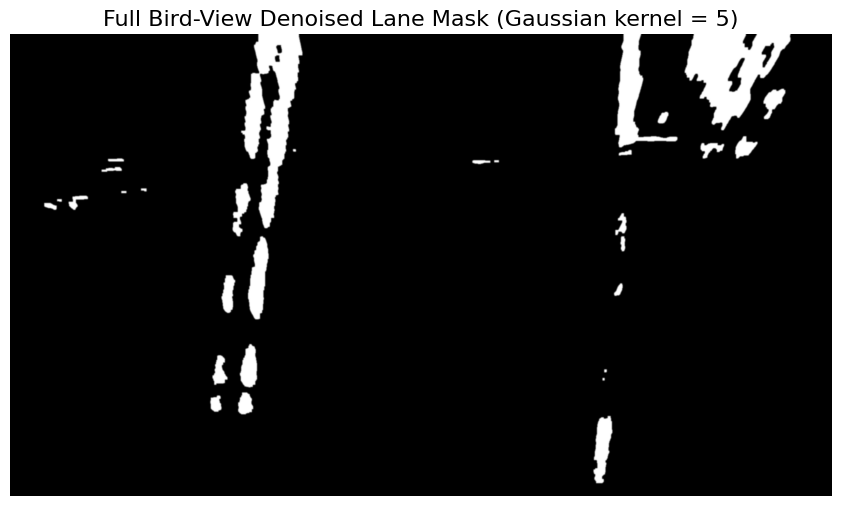

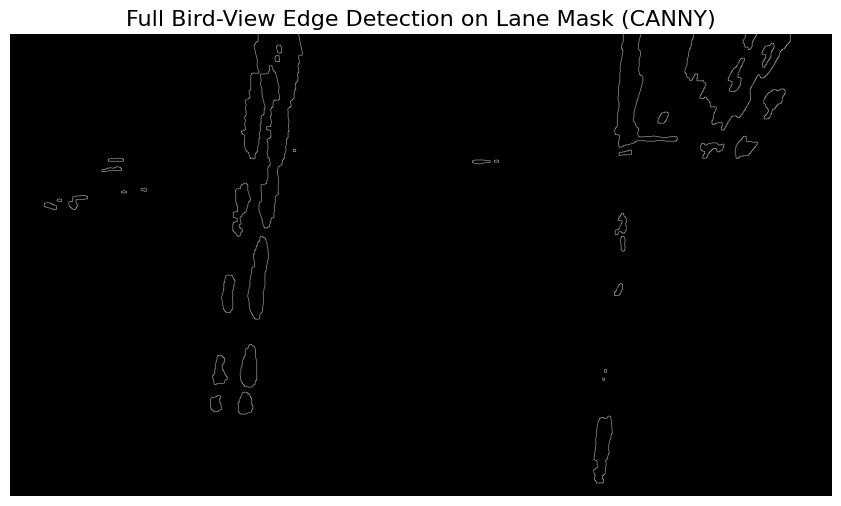

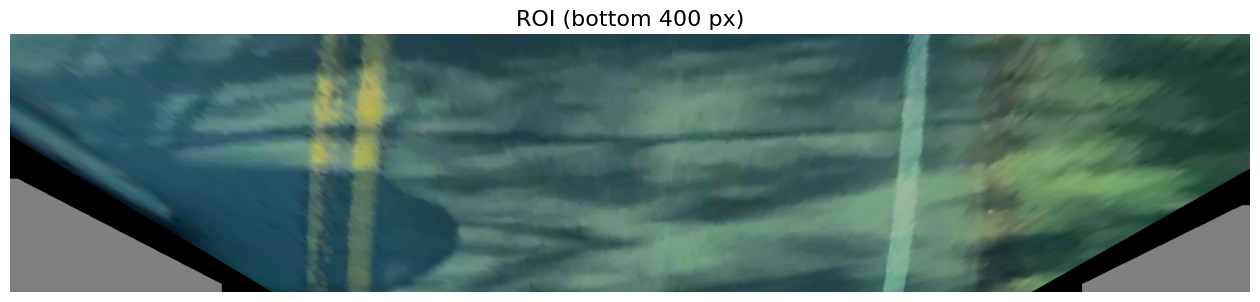

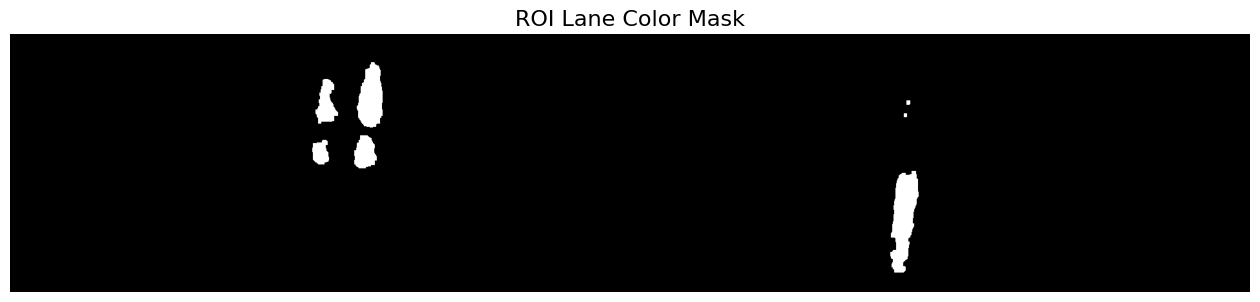

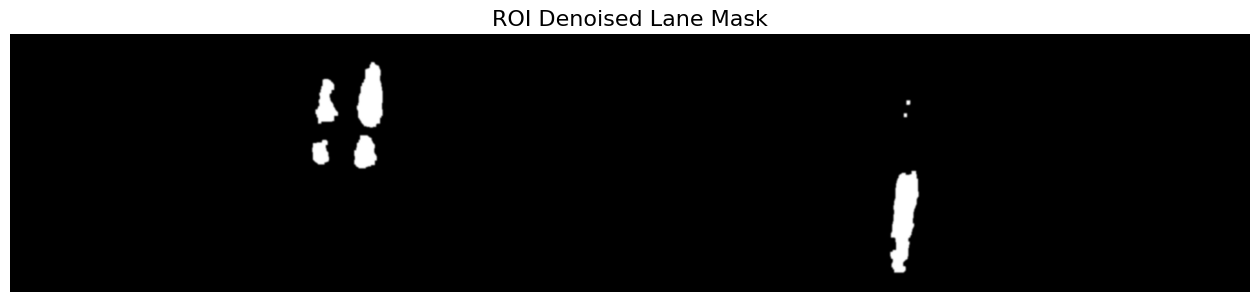

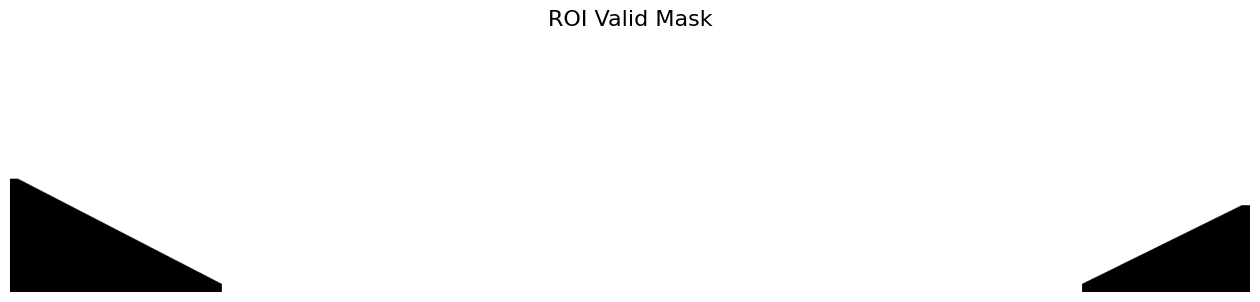

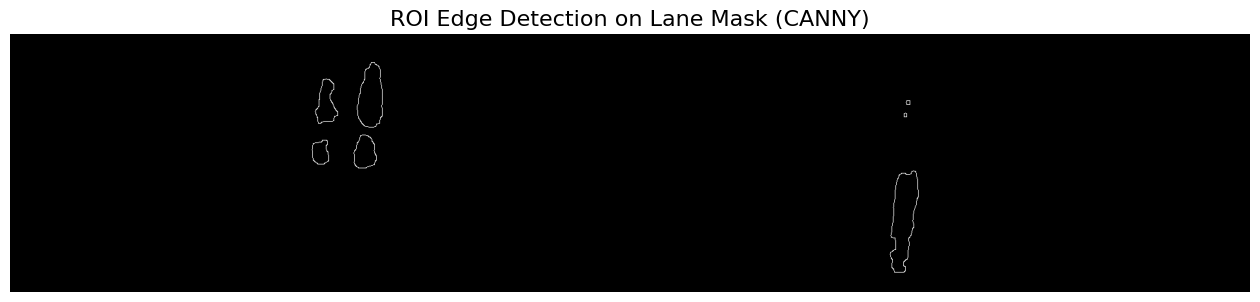

In [166]:
def crop_roi(img, roi_height=400):
    h, w = img.shape[:2]
    roi_h = min(roi_height, h)
    y0 = h - roi_h
    return img[y0:h, :], y0


def denoise(img, ksize=5):
    if ksize % 2 == 0:
        ksize += 1
    return cv2.GaussianBlur(img, (ksize, ksize), 0)


def edge_detect(gray_img, method="canny"):
    method = method.lower()

    if method == "canny":
        return cv2.Canny(gray_img, CONFIG["canny_low"], CONFIG["canny_high"])

    if method == "sobel":
        sx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=CONFIG["sobel_ksize"])
        sy = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=CONFIG["sobel_ksize"])
        mag = np.sqrt(sx**2 + sy**2)
        mag = np.uint8(255 * mag / (mag.max() + 1e-6))
        _, edges = cv2.threshold(mag, CONFIG["sobel_thresh"], 255, cv2.THRESH_BINARY)
        return edges

    raise ValueError("method must be 'canny' or 'sobel'")


def fill_invalid_region_with_gray(frame_bgr, valid_mask, fill_value=128):
    filled = frame_bgr.copy()
    invalid = (valid_mask == 0)

    for c in range(3):
        filled[:, :, c][invalid] = fill_value

    return filled

def normalize_illumination_bgr(frame_bgr, blur_ksize=101):
    """
    Suppress large-scale illumination variation (e.g. tree shadows)
    by dividing the image by a heavily blurred background estimate.
    """
    if blur_ksize % 2 == 0:
        blur_ksize += 1

    frame_f = frame_bgr.astype(np.float32) + 1.0
    background = cv2.GaussianBlur(frame_f, (blur_ksize, blur_ksize), 0)

    normalized = frame_f / (background + 1e-6) * 128.0
    normalized = np.clip(normalized, 0, 255).astype(np.uint8)
    return normalized


def apply_clahe_to_lightness(frame_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Improve local contrast on the lightness channel only.
    """
    hls = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HLS)
    h, l, s = cv2.split(hls)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)

    hls_eq = cv2.merge([h, l_eq, s])
    return cv2.cvtColor(hls_eq, cv2.COLOR_HLS2BGR)

def lane_color_mask(frame_bgr):
    """
    Keep likely yellow and white lane markings while suppressing shadows/background.
    """
    hls = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HLS)
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    # White lane mask
    white_mask = cv2.inRange(
        hls,
        np.array([0, 150, 0], dtype=np.uint8),
        np.array([255, 255, 145], dtype=np.uint8)
    )
    # Yellow lane mask
    yellow_mask = cv2.inRange(
        hsv,
        np.array([15, 60, 80], dtype=np.uint8),
        np.array([40, 255, 255], dtype=np.uint8)
    )

    mask = cv2.bitwise_or(white_mask, yellow_mask)

    # Morphological cleanup
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask


def preprocess(frame_bgr, valid_mask=None):
    working_bgr = frame_bgr.copy()

    if valid_mask is not None:
        working_bgr = fill_invalid_region_with_gray(working_bgr, valid_mask, fill_value=128)

    # Step 1: color-based lane filtering
    full_lane_mask = lane_color_mask(working_bgr)

    # Remove invalid warped region
    if valid_mask is not None:
        full_lane_mask = cv2.bitwise_and(full_lane_mask, full_lane_mask, mask=valid_mask)

    # Step 2: denoise mask
    full_denoised = denoise(full_lane_mask, CONFIG["denoise_kernel"])

    # Step 3: edge detection
    full_edges = edge_detect(full_denoised, method=CONFIG["edge_method"])

    # Step 4: crop ROI
    roi_bgr, roi_y0 = crop_roi(working_bgr, CONFIG["roi_height"])
    roi_lane_mask, _ = crop_roi(full_lane_mask, CONFIG["roi_height"])
    roi_denoised, _ = crop_roi(full_denoised, CONFIG["roi_height"])
    roi_edges, _ = crop_roi(full_edges, CONFIG["roi_height"])

    roi_mask = None
    if valid_mask is not None:
        roi_mask, _ = crop_roi(valid_mask, CONFIG["roi_height"])

    return (
        working_bgr,
        full_lane_mask,
        full_denoised,
        full_edges,
        roi_bgr,
        roi_lane_mask,
        roi_denoised,
        roi_edges,
        roi_y0,
        roi_mask,
    )


def show_image(img, title="", cmap=None, is_bgr=False, figsize=(16, 6)):
    plt.figure(figsize=figsize)
    if is_bgr:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
    else:
        plt.imshow(img, cmap=cmap, vmin=0, vmax=255)
    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.show()


# Build valid warped-region mask
valid_mask = np.ones((H, W), dtype=np.uint8) * 255
warped_valid_mask = cv2.warpPerspective(valid_mask, H_mat, (W, H))

# Ignore only a modest border near invalid warped edges
ignore_border_px = 25
kernel = np.ones((ignore_border_px, ignore_border_px), np.uint8)
warped_valid_mask = cv2.erode(warped_valid_mask, kernel, iterations=1)

(
    working_bgr,
    full_lane_mask,
    full_denoised,
    full_edges,
    roi_bgr,
    roi_lane_mask,
    roi_denoised,
    roi_edges,
    roi_y0,
    roi_mask,
) = preprocess(warped_sample, valid_mask=warped_valid_mask)

show_image(
    warped_sample,
    title="Warped Bird-View Frame (raw)",
    is_bgr=True
)

show_image(
    working_bgr,
    title="Warped Bird-View Frame after Neutral Fill in Invalid Regions",
    is_bgr=True
)

show_image(
    warped_valid_mask,
    title="Warped Valid Region Mask",
    cmap="gray"
)

show_image(
    full_lane_mask,
    title="Full Bird-View Lane Color Mask (white + yellow)",
    cmap="gray"
)

show_image(
    full_denoised,
    title=f"Full Bird-View Denoised Lane Mask (Gaussian kernel = {CONFIG['denoise_kernel']})",
    cmap="gray"
)

show_image(
    full_edges,
    title=f"Full Bird-View Edge Detection on Lane Mask ({CONFIG['edge_method'].upper()})",
    cmap="gray"
)

show_image(
    roi_bgr,
    title=f"ROI (bottom {CONFIG['roi_height']} px)",
    is_bgr=True
)

show_image(
    roi_lane_mask,
    title="ROI Lane Color Mask",
    cmap="gray"
)

show_image(
    roi_denoised,
    title="ROI Denoised Lane Mask",
    cmap="gray"
)

show_image(
    roi_mask,
    title="ROI Valid Mask",
    cmap="gray"
)

show_image(
    roi_edges,
    title=f"ROI Edge Detection on Lane Mask ({CONFIG['edge_method'].upper()})",
    cmap="gray"
)

## Step 2: Hough Lane Candidates

Hough transform is used to detect candidate line segments (`cv2.HoughLinesP`).

- Raw segments are filtered by slope to remove near-horizontal clutter.
- Segments are split into left/right groups using slope sign in bird-view ROI.
- Each group is extrapolated to ROI vertical bounds using a fitted line model.

This corresponds to the required concept: **Hough peak lines -> extrapolated lane lines**.

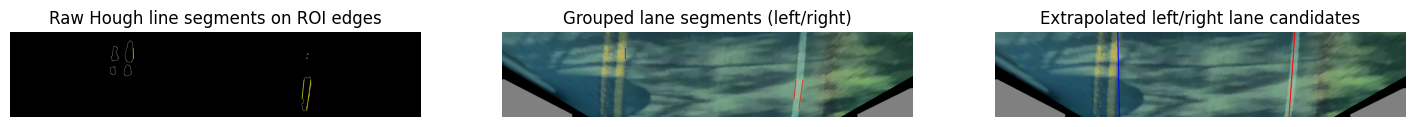

Detected segments: total=3, left=1, right=2
left_line: (573, 0, 581, 399)
right_line: (1401, 0, 1373, 399)


In [167]:
def hough_lines(edges):
    """
    Detect raw line segments using probabilistic Hough transform.
    Returns a list of segments in the form [x1, y1, x2, y2].
    """
    lines = cv2.HoughLinesP(
        edges,
        rho=CONFIG["hough_rho"],
        theta=CONFIG["hough_theta"],
        threshold=CONFIG["hough_threshold"],
        minLineLength=CONFIG["hough_min_line_length"],
        maxLineGap=CONFIG["hough_max_line_gap"],
    )

    if lines is None:
        return []

    return lines.reshape(-1, 4)


def line_length(x1, y1, x2, y2):
    return float(np.hypot(x2 - x1, y2 - y1))


def split_left_right(lines, img_width, min_abs_slope=0.35, min_length=20):
    """
    Split raw Hough segments into left/right candidate groups.

    Improvement over the basic version:
    - remove short segments
    - remove near-horizontal clutter
    - use both x-position and slope for grouping
    """
    left, right = [], []
    x_mid = img_width / 2.0

    for x1, y1, x2, y2 in lines:
        seg_len = line_length(x1, y1, x2, y2)
        if seg_len < min_length:
            continue

        dx = x2 - x1
        dy = y2 - y1

        # Avoid divide-by-zero for near-vertical lines
        if abs(dx) < 1e-6:
            slope = np.sign(dy) * 1e6
        else:
            slope = dy / dx

        # Remove near-horizontal clutter
        if abs(slope) < min_abs_slope:
            continue

        x_center = 0.5 * (x1 + x2)

        # Primary split by x position in bird-view
        # Secondary check by slope direction to reduce obvious mismatches
        if x_center < x_mid:
            left.append((x1, y1, x2, y2))
        else:
            right.append((x1, y1, x2, y2))

    return left, right


def extrapolate_line(line_group, y_min, y_max, img_width):
    """
    Fit x = m*y + b using all segment endpoints and extrapolate
    to the full ROI vertical bounds.
    """
    if len(line_group) == 0:
        return None

    xs = []
    ys = []

    for x1, y1, x2, y2 in line_group:
        xs.extend([x1, x2])
        ys.extend([y1, y2])

    ys = np.array(ys, dtype=np.float32)
    xs = np.array(xs, dtype=np.float32)

    if len(xs) < 2:
        return None

    m, b = np.polyfit(ys, xs, 1)

    x_at_ymin = int(np.clip(m * y_min + b, 0, img_width - 1))
    x_at_ymax = int(np.clip(m * y_max + b, 0, img_width - 1))

    return (x_at_ymin, int(y_min), x_at_ymax, int(y_max))


def draw_segments(img_bgr, segments, color=(0, 255, 255), thickness=2):
    out = img_bgr.copy()
    for x1, y1, x2, y2 in segments:
        cv2.line(out, (int(x1), int(y1)), (int(x2), int(y2)), color, thickness)
    return out


def draw_line_if_valid(img_bgr, line, color=(255, 0, 0), thickness=4):
    out = img_bgr.copy()
    if line is not None:
        x1, y1, x2, y2 = line
        cv2.line(out, (x1, y1), (x2, y2), color, thickness)
    return out


# -------------------------
# Run Hough candidate stage
# -------------------------
lines = hough_lines(roi_edges)

left_group, right_group = split_left_right(
    lines,
    img_width=roi_bgr.shape[1],
    min_abs_slope=CONFIG["min_abs_slope"],
    min_length=20,
)

# 1) Raw segments visualization
raw_vis = cv2.cvtColor(roi_edges, cv2.COLOR_GRAY2BGR)
raw_vis = draw_segments(raw_vis, lines, color=(0, 255, 255), thickness=2)

# 2) Grouped segments visualization
group_vis = roi_bgr.copy()
group_vis = draw_segments(group_vis, left_group, color=(255, 0, 0), thickness=2)   # blue
group_vis = draw_segments(group_vis, right_group, color=(0, 0, 255), thickness=2)  # red

# 3) Extrapolated lane candidates
extrap_vis = roi_bgr.copy()
y_min, y_max = 0, roi_bgr.shape[0] - 1

left_line = extrapolate_line(left_group, y_min, y_max, roi_bgr.shape[1])
right_line = extrapolate_line(right_group, y_min, y_max, roi_bgr.shape[1])

extrap_vis = draw_line_if_valid(extrap_vis, left_line, color=(255, 0, 0), thickness=4)
extrap_vis = draw_line_if_valid(extrap_vis, right_line, color=(0, 0, 255), thickness=4)

# -------------------------
# Show results
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(cv2.cvtColor(raw_vis, cv2.COLOR_BGR2RGB))
axes[0].set_title("Raw Hough line segments on ROI edges")

axes[1].imshow(cv2.cvtColor(group_vis, cv2.COLOR_BGR2RGB))
axes[1].set_title("Grouped lane segments (left/right)")

axes[2].imshow(cv2.cvtColor(extrap_vis, cv2.COLOR_BGR2RGB))
axes[2].set_title("Extrapolated left/right lane candidates")

for ax in axes:
    ax.axis("off")

plt.show()

print(f"Detected segments: total={len(lines)}, left={len(left_group)}, right={len(right_group)}")
print("left_line:", left_line)
print("right_line:", right_line)

## Step 3: Polynomial Fitting and Lane Mesh

Straight-line extrapolation is insufficient on curves, so lane boundaries are refined with polynomial fitting.

Method:

- Collect endpoints from left/right Hough segment groups.
- Fit `x = f(y)` in bird view (`np.polyfit`), degree 2 by default.
- Evaluate fitted curves on sampled `y` values.
- Build lane polygon (`left curve + reversed right curve`) and fill it.
- Back-project the overlay to original perspective with inverse homography and alpha blend.

In [168]:
def collect_points_from_lines(line_group):
    """
    Convert a group of Hough line segments into a set of 2D points.
    Each segment contributes its two endpoints.
    """
    points = []
    for x1, y1, x2, y2 in line_group:
        points.append([x1, y1])
        points.append([x2, y2])

    if len(points) == 0:
        return np.empty((0, 2), dtype=np.float32)

    return np.array(points, dtype=np.float32)


def fit_poly(points_xy, deg=2):
    """
    Fit x = f(y) polynomial to a set of points in bird-view ROI.
    """
    if len(points_xy) < deg + 1:
        return None

    x = points_xy[:, 0]
    y = points_xy[:, 1]

    coeffs = np.polyfit(y, x, deg)
    return coeffs


def eval_poly(poly_coeffs, y_vals):
    """
    Evaluate fitted polynomial x=f(y) at sampled y positions.
    """
    if poly_coeffs is None:
        return None

    return np.polyval(poly_coeffs, y_vals)


def build_lane_polygon(left_poly, right_poly, y_vals, width):
    """
    Build a filled lane polygon from left and right fitted curves.
    """
    lx = eval_poly(left_poly, y_vals)
    rx = eval_poly(right_poly, y_vals)

    if lx is None or rx is None:
        return None, None, None

    lx = np.clip(lx, 0, width - 1)
    rx = np.clip(rx, 0, width - 1)

    left_pts = np.stack([lx, y_vals], axis=1)
    right_pts = np.stack([rx, y_vals], axis=1)

    # Reverse the right side so that polygon points go around the lane boundary
    polygon = np.vstack([left_pts, right_pts[::-1]]).astype(np.int32)

    return polygon, left_pts.astype(np.int32), right_pts.astype(np.int32)


def warp_back(mask_or_overlay, H_inv, out_size):
    """
    Warp bird-view overlay back to original perspective.
    """
    return cv2.warpPerspective(mask_or_overlay, H_inv, out_size)


def process_frame(frame_bgr, H_mat, H_inv):
    h, w = frame_bgr.shape[:2]

    # 1. Warp to bird-view
    bird = cv2.warpPerspective(frame_bgr, H_mat, (w, h))

    # 2. Build valid mask the same way as before
    valid_mask = np.ones((h, w), dtype=np.uint8) * 255
    warped_valid_mask = cv2.warpPerspective(valid_mask, H_mat, (w, h))

    # Optional: extra ignored corner regions
    corner_mask = np.ones((h, w), dtype=np.uint8) * 255

    left_ignore_poly = np.array([
        [0, h],
        [0, h - 160],
        [180, h],
    ], dtype=np.int32)

    right_ignore_poly = np.array([
        [w, h],
        [w, h - 160],
        [w - 180, h],
    ], dtype=np.int32)

    cv2.fillPoly(corner_mask, [left_ignore_poly], 0)
    cv2.fillPoly(corner_mask, [right_ignore_poly], 0)

    warped_valid_mask = cv2.bitwise_and(warped_valid_mask, corner_mask)

    # 3. Preprocess with your NEW pipeline
    (
        working_bgr,
        full_lane_mask,
        full_denoised,
        full_edges,
        roi_bgr,
        roi_lane_mask,
        roi_denoised,
        roi_edges,
        roi_y0,
        roi_mask,
    ) = preprocess(bird, valid_mask=warped_valid_mask)

    # 4. Hough line candidates
    lines = hough_lines(roi_edges)

    left_group, right_group = split_left_right(
        lines,
        img_width=roi_bgr.shape[1],
        min_abs_slope=CONFIG["min_abs_slope"],
        min_length=20,
    )

    # 5. Collect points for polynomial fitting
    left_pts = collect_points_from_lines(left_group)
    right_pts = collect_points_from_lines(right_group)

    left_poly = fit_poly(left_pts, deg=CONFIG["poly_degree"])
    right_poly = fit_poly(right_pts, deg=CONFIG["poly_degree"])

    # 6. Sample y values and build lane polygon
    y_vals = np.linspace(0, roi_bgr.shape[0] - 1, 180)

    polygon, left_curve, right_curve = build_lane_polygon(
        left_poly,
        right_poly,
        y_vals,
        roi_bgr.shape[1]
    )

    # 7. Draw lane mesh in ROI
    lane_overlay_roi = np.zeros_like(roi_bgr)

    if polygon is not None:
        cv2.fillPoly(lane_overlay_roi, [polygon], CONFIG["lane_fill_color"])

        if left_curve is not None:
            cv2.polylines(
                lane_overlay_roi,
                [left_curve.reshape(-1, 1, 2)],
                False,
                CONFIG["lane_line_color"],
                CONFIG["line_thickness"],
            )

        if right_curve is not None:
            cv2.polylines(
                lane_overlay_roi,
                [right_curve.reshape(-1, 1, 2)],
                False,
                CONFIG["lane_line_color"],
                CONFIG["line_thickness"],
            )

    # 8. Put ROI overlay back into full bird-view canvas
    lane_overlay_bird = np.zeros_like(bird)
    lane_overlay_bird[roi_y0:, :] = lane_overlay_roi

    # 9. Warp back to original frame
    lane_overlay_orig = warp_back(lane_overlay_bird, H_inv, (w, h))

    # 10. Alpha blend with original image
    out = cv2.addWeighted(frame_bgr, 1.0, lane_overlay_orig, CONFIG["overlay_alpha"], 0)

    debug = {
        "bird": bird,
        "roi_edges": roi_edges,
        "roi_lane_mask": roi_lane_mask,
        "roi_y0": roi_y0,
        "left_poly": left_poly,
        "right_poly": right_poly,
        "lane_overlay_bird": lane_overlay_bird,
        "output": out,
    }

    return out, debug

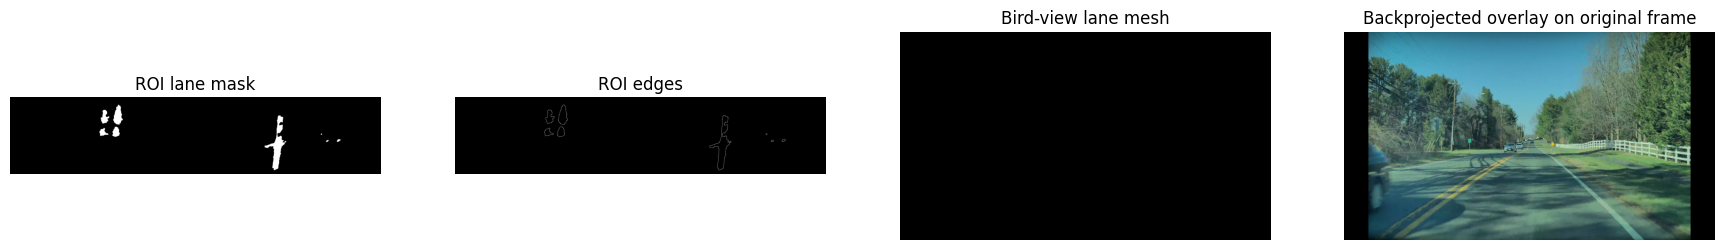

In [164]:
out_frame, debug = process_frame(sample_frame, H_mat, H_inv)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(cv2.cvtColor(debug["roi_lane_mask"], cv2.COLOR_GRAY2RGB))
axes[0].set_title("ROI lane mask")

axes[1].imshow(cv2.cvtColor(debug["roi_edges"], cv2.COLOR_GRAY2RGB))
axes[1].set_title("ROI edges")

axes[2].imshow(cv2.cvtColor(debug["lane_overlay_bird"], cv2.COLOR_BGR2RGB))
axes[2].set_title("Bird-view lane mesh")

axes[3].imshow(cv2.cvtColor(out_frame, cv2.COLOR_BGR2RGB))
axes[3].set_title("Backprojected overlay on original frame")

for ax in axes:
    ax.axis("off")

plt.show()

# video

In [169]:
import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Utility helpers
# -----------------------------
def collect_points_from_lines(line_group):
    points = []
    for x1, y1, x2, y2 in line_group:
        points.append([x1, y1])
        points.append([x2, y2])

    if len(points) == 0:
        return np.empty((0, 2), dtype=np.float32)

    return np.array(points, dtype=np.float32)


def fit_poly(points_xy, deg=2):
    """
    Fit x = f(y) polynomial in bird-view ROI.
    """
    if points_xy is None or len(points_xy) < deg + 1:
        return None

    x = points_xy[:, 0]
    y = points_xy[:, 1]

    try:
        coeffs = np.polyfit(y, x, deg)
        return coeffs
    except Exception:
        return None


def eval_poly(poly_coeffs, y_vals):
    if poly_coeffs is None:
        return None
    return np.polyval(poly_coeffs, y_vals)


def build_lane_polygon(left_poly, right_poly, y_vals, width):
    """
    Build polygon from left and right fitted curves.
    """
    lx = eval_poly(left_poly, y_vals)
    rx = eval_poly(right_poly, y_vals)

    if lx is None or rx is None:
        return None, None, None

    lx = np.clip(lx, 0, width - 1)
    rx = np.clip(rx, 0, width - 1)

    left_pts = np.stack([lx, y_vals], axis=1).astype(np.int32)
    right_pts = np.stack([rx, y_vals], axis=1).astype(np.int32)

    polygon = np.vstack([left_pts, right_pts[::-1]]).astype(np.int32)

    return polygon, left_pts, right_pts


def warp_back(mask_or_overlay, H_inv, out_size):
    return cv2.warpPerspective(mask_or_overlay, H_inv, out_size)


def normalize_poly_coeffs(poly_coeffs):
    """
    Normalize polynomial coefficients to degree-2 form [A, B, C].
    """
    if poly_coeffs is None:
        return None

    poly_coeffs = np.array(poly_coeffs, dtype=np.float32)

    if len(poly_coeffs) == 3:
        return poly_coeffs
    elif len(poly_coeffs) == 2:
        return np.array([0.0, poly_coeffs[0], poly_coeffs[1]], dtype=np.float32)
    else:
        return None


def classify_turn_from_center_shift(left_poly, right_poly, roi_h, straight_px_thresh=12):
    """
    Classify turn direction using the horizontal shift of the lane centerline
    between the bottom and upper part of the ROI.
    """
    if left_poly is None or right_poly is None:
        return "Unknown", None

    left_poly = np.array(left_poly, dtype=np.float32)
    right_poly = np.array(right_poly, dtype=np.float32)

    if len(left_poly) == 2:
        left_poly = np.array([0.0, left_poly[0], left_poly[1]], dtype=np.float32)
    if len(right_poly) == 2:
        right_poly = np.array([0.0, right_poly[0], right_poly[1]], dtype=np.float32)

    center_poly = 0.5 * (left_poly + right_poly)

    y_bottom = roi_h - 1
    y_top = int(0.2 * roi_h)

    x_bottom = np.polyval(center_poly, y_bottom)
    x_top = np.polyval(center_poly, y_top)

    shift_px = float(x_top - x_bottom)

    if abs(shift_px) < straight_px_thresh:
        turn = "Straight"
    elif shift_px > 0:
        turn = "Right"
    else:
        turn = "Left"

    return turn, shift_px


def estimate_curvature_and_turn(left_poly, right_poly, y_eval, lane_width_px, roi_h, straight_px_thresh=12):
    """
    Rough curvature estimate using average centerline.
    Assumes x = f(y).

    Turn direction is classified using centerline horizontal shift,
    with a straight threshold to reduce jitter.
    """
    if left_poly is None or right_poly is None or lane_width_px is None or lane_width_px <= 1:
        return None, "Unknown", None

    p_left = np.array(left_poly, dtype=np.float64)
    p_right = np.array(right_poly, dtype=np.float64)

    if len(p_left) == 2:
        p_left = np.array([0.0, p_left[0], p_left[1]], dtype=np.float64)
    if len(p_right) == 2:
        p_right = np.array([0.0, p_right[0], p_right[1]], dtype=np.float64)

    if len(p_left) != 3 or len(p_right) != 3:
        return None, "Unknown", None

    # Average left and right poly as approximate centerline
    p = 0.5 * (p_left + p_right)
    A_px, B_px, C_px = p

    # Pixel -> meter scaling
    xm_per_pix = 3.7 / max(lane_width_px, 1.0)
    ym_per_pix = 30.0 / 400.0

    # Convert coefficients from pixel domain to meter domain
    A_m = xm_per_pix * A_px / (ym_per_pix ** 2)
    B_m = xm_per_pix * B_px / ym_per_pix

    y_m = y_eval * ym_per_pix

    denom = abs(2 * A_m)
    if denom < 1e-8:
        curvature = 1e9
    else:
        curvature = ((1 + (2 * A_m * y_m + B_m) ** 2) ** 1.5) / denom

    turn, shift_px = classify_turn_from_center_shift(
        p_left, p_right, roi_h=roi_h, straight_px_thresh=straight_px_thresh
    )

    return float(curvature), turn, shift_px


# -----------------------------
# Main single-frame pipeline
# -----------------------------
def process_frame(frame_bgr, H_mat, H_inv):
    h, w = frame_bgr.shape[:2]

    # 1) Warp original frame to bird view
    bird = cv2.warpPerspective(frame_bgr, H_mat, (w, h))

    # 2) Build valid warped mask
    valid_mask = np.ones((h, w), dtype=np.uint8) * 255
    warped_valid_mask = cv2.warpPerspective(valid_mask, H_mat, (w, h))

    # 3) Add extra ignored lower-corner regions
    corner_mask = np.ones((h, w), dtype=np.uint8) * 255

    left_ignore_poly = np.array([
        [0, h],
        [0, h - 160],
        [180, h],
    ], dtype=np.int32)

    right_ignore_poly = np.array([
        [w, h],
        [w, h - 160],
        [w - 180, h],
    ], dtype=np.int32)

    cv2.fillPoly(corner_mask, [left_ignore_poly], 0)
    cv2.fillPoly(corner_mask, [right_ignore_poly], 0)

    warped_valid_mask = cv2.bitwise_and(warped_valid_mask, corner_mask)

    # 4) Preprocess using your current pipeline
    (
        working_bgr,
        full_lane_mask,
        full_denoised,
        full_edges,
        roi_bgr,
        roi_lane_mask,
        roi_denoised,
        roi_edges,
        roi_y0,
        roi_mask,
    ) = preprocess(bird, valid_mask=warped_valid_mask)

    # 5) Hough candidate lines
    lines = hough_lines(roi_edges)

    left_group, right_group = split_left_right(
        lines,
        img_width=roi_bgr.shape[1],
        min_abs_slope=CONFIG["min_abs_slope"],
        min_length=20,
    )

    # 6) Collect points and fit polynomials
    left_pts = collect_points_from_lines(left_group)
    right_pts = collect_points_from_lines(right_group)

    left_poly = fit_poly(left_pts, deg=CONFIG["poly_degree"])
    right_poly = fit_poly(right_pts, deg=CONFIG["poly_degree"])

    # Fallback: if polynomial fit fails, try line extrapolation result converted to points
    if left_poly is None and len(left_group) > 0:
        left_line = extrapolate_line(left_group, 0, roi_bgr.shape[0] - 1, roi_bgr.shape[1])
        if left_line is not None:
            temp_pts = np.array(
                [[left_line[0], left_line[1]], [left_line[2], left_line[3]]],
                dtype=np.float32
            )
            left_poly_linear = fit_poly(temp_pts, deg=1)
            if left_poly_linear is not None:
                left_poly = np.array([0.0, left_poly_linear[0], left_poly_linear[1]], dtype=np.float32)

    if right_poly is None and len(right_group) > 0:
        right_line = extrapolate_line(right_group, 0, roi_bgr.shape[0] - 1, roi_bgr.shape[1])
        if right_line is not None:
            temp_pts = np.array(
                [[right_line[0], right_line[1]], [right_line[2], right_line[3]]],
                dtype=np.float32
            )
            right_poly_linear = fit_poly(temp_pts, deg=1)
            if right_poly_linear is not None:
                right_poly = np.array([0.0, right_poly_linear[0], right_poly_linear[1]], dtype=np.float32)

    # Normalize both to degree-2 form
    left_poly = normalize_poly_coeffs(left_poly)
    right_poly = normalize_poly_coeffs(right_poly)

    # 7) Build polygon in ROI
    y_vals = np.linspace(0, roi_bgr.shape[0] - 1, 300)
    polygon, left_curve, right_curve = build_lane_polygon(
        left_poly,
        right_poly,
        y_vals,
        roi_bgr.shape[1],
    )

    lane_overlay_roi = np.zeros_like(roi_bgr)

    if polygon is not None:
        cv2.fillPoly(lane_overlay_roi, [polygon], CONFIG["lane_fill_color"])

        if left_curve is not None:
            cv2.polylines(
                lane_overlay_roi,
                [left_curve.reshape(-1, 1, 2)],
                False,
                CONFIG["lane_line_color"],
                CONFIG["line_thickness"],
            )

        if right_curve is not None:
            cv2.polylines(
                lane_overlay_roi,
                [right_curve.reshape(-1, 1, 2)],
                False,
                CONFIG["lane_line_color"],
                CONFIG["line_thickness"],
            )

        # Optional centerline
        if left_poly is not None and right_poly is not None:
            center_poly = 0.5 * (np.array(left_poly) + np.array(right_poly))
            cx = np.polyval(center_poly, y_vals)
            cx = np.clip(cx, 0, roi_bgr.shape[1] - 1)
            center_pts = np.stack([cx, y_vals], axis=1).astype(np.int32)
            cv2.polylines(
                lane_overlay_roi,
                [center_pts.reshape(-1, 1, 2)],
                False,
                (0, 255, 255),
                2,
            )

    # 8) Put ROI overlay back into full bird-view canvas
    lane_overlay_bird = np.zeros_like(bird)
    lane_overlay_bird[roi_y0:, :] = lane_overlay_roi

    # 9) Warp back to original image
    lane_overlay_orig = warp_back(lane_overlay_bird, H_inv, (w, h))

    # 10) Blend on original frame
    out = cv2.addWeighted(frame_bgr, 1.0, lane_overlay_orig, CONFIG["overlay_alpha"], 0)

    # 11) Curvature + turn text
    curvature_text = "Radius of Curvature: N/A"
    turn_text = "Turn: Unknown"
    shift_text = "Center shift: N/A"

    if left_poly is not None and right_poly is not None:
        y_eval = roi_bgr.shape[0] - 1
        lx = np.polyval(left_poly, y_eval)
        rx = np.polyval(right_poly, y_eval)
        lane_width_px = abs(rx - lx)

        curvature, turn, shift_px = estimate_curvature_and_turn(
            left_poly,
            right_poly,
            y_eval,
            lane_width_px,
            roi_h=roi_bgr.shape[0],
            straight_px_thresh=12,
        )

        if curvature is not None:
            curvature_text = f"Radius of Curvature: {curvature:,.1f} m"
            turn_text = f"Turn: {turn}"

        if shift_px is not None:
            shift_text = f"Center shift: {shift_px:.1f} px"

    cv2.putText(out, curvature_text, (30, 45),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
    cv2.putText(out, turn_text, (30, 80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
    cv2.putText(out, shift_text, (30, 115),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    debug = {
        "bird": bird,
        "roi_lane_mask": roi_lane_mask,
        "roi_edges": roi_edges,
        "left_poly": left_poly,
        "right_poly": right_poly,
        "lane_overlay_bird": lane_overlay_bird,
        "output": out,
    }

    return out, debug


# -----------------------------
# Video processing
# -----------------------------
def process_video(input_path, output_path, H_mat, H_inv):
    fps, (w, h), n_frames = load_video_info(input_path)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    if not writer.isOpened():
        raise RuntimeError(f"Cannot open VideoWriter for: {output_path}")

    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {input_path}")

    idx = 0
    fail_count = 0
    start_time = time.time()

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        try:
            processed, _ = process_frame(frame, H_mat, H_inv)
        except Exception as e:
            fail_count += 1
            print(f"[WARN] Frame {idx} failed: {e}")
            processed = frame.copy()
            cv2.putText(
                processed,
                "Lane detection failed on this frame",
                (30, 45),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 0, 255),
                2,
            )

        writer.write(processed)
        idx += 1

        if idx % 50 == 0:
            elapsed = time.time() - start_time
            print(f"Processed {idx}/{n_frames} frames | elapsed {elapsed:.1f}s | failures {fail_count}")

    cap.release()
    writer.release()

    total_time = time.time() - start_time
    print(f"Saved: {output_path}")
    print(f"Done. Frames processed: {idx}, failures: {fail_count}, total time: {total_time:.1f}s")

    return output_path


# -----------------------------
# Run final video generation
# -----------------------------
base = os.path.splitext(os.path.basename(CONFIG["input_video"]))[0]
output_path = os.path.join(CONFIG["output_dir"], f"{base}{CONFIG['output_suffix']}")

result_path = process_video(CONFIG["input_video"], output_path, H_mat, H_inv)
print("Final video:", result_path)

Processed 50/839 frames | elapsed 1.2s | failures 0
Processed 100/839 frames | elapsed 2.2s | failures 0
Processed 150/839 frames | elapsed 3.3s | failures 0
Processed 200/839 frames | elapsed 4.5s | failures 0
Processed 250/839 frames | elapsed 5.6s | failures 0
Processed 300/839 frames | elapsed 6.8s | failures 0
Processed 350/839 frames | elapsed 7.9s | failures 0
Processed 400/839 frames | elapsed 8.9s | failures 0
Processed 450/839 frames | elapsed 9.9s | failures 0
Processed 500/839 frames | elapsed 11.0s | failures 0
Processed 550/839 frames | elapsed 12.0s | failures 0
Processed 600/839 frames | elapsed 13.1s | failures 0
Processed 650/839 frames | elapsed 14.2s | failures 0
Processed 700/839 frames | elapsed 15.3s | failures 0
Processed 750/839 frames | elapsed 16.3s | failures 0
Processed 800/839 frames | elapsed 17.4s | failures 0
Saved: outputs/import_video_lane.mp4
Done. Frames processed: 839, failures: 0, total time: 18.3s
Final video: outputs/import_video_lane.mp4
